# 07 — Real-time benchmark: can the cascade run live?

**No training.** The deployment-feasibility companion to notebook 05's cold-start
measurement, on the deployed 09_end2end cascade (frozen `BlackboxGRLSTM` predictor →
`GainPriorWSE2ELSTM`). Three questions, answered on a single CPU thread (the
pessimistic plugin-audio-thread regime):

1. **Throughput** — real-time factor (RTF) of each stage and the full cascade in
   bulk streaming.
2. **Per-buffer latency** — wall time per processing call at plugin-style buffer
   sizes (128 … 4096 samples), mean *and* p99 against the buffer's time budget.
   In real-time audio the p99 is what causes dropouts, not the mean.
3. **Exactness & algorithmic latency** — verification that chunked stateful
   streaming is numerically identical to one full forward at every benchmarked
   buffer size (the property all eval numbers rely on), plus the accounting of
   *intrinsic* latency, which is independent of compute speed.

Note: stage 1 is labelled **"detector"** in the tables/plots below, but it is now the
learned **blackbox** GR predictor (conv frame-encoder + dilated temporal stack +
LSTM), which is materially heavier than its fixed-detector-bank twin — so read its
cost off the tables rather than assuming it is near-free.

Interpretation bounds: everything here is **eager PyTorch** — the pessimistic
bound. Compiled inference of this architecture class (TorchScript/ONNX, or the
RTNeural-style C++ engines used to deploy LSTM32 VA models) typically gains an
order of magnitude on exactly these small recurrent networks, so headroom
measured here only improves in a real plugin.

Alignment constraints (structural, not performance): the gain stage accepts only
128-sample-multiple chunks (`TVFiLMCond` block), the predictor only 256-sample
multiples (frame hop) — non-multiples are rejected/misaligned by construction, so
the natural scheduling unit of the cascade is one 256-sample frame.

> ≈ 3–5 min on CPU.

In [1]:
# -- 0. Setup -----------------------------------------------------------------
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from exp_common import (
    SR, ensure_eval_out, load_blackbox_gr, load_gain_prior_e2e, load_pair,
    load_split, pairs_from_keys, params_for, stream_detector_gr, stream_gain_prior,
)

# Deployed 09_end2end cascade: frozen blackbox GR predictor (stage 1, learned
# conv frontend + LSTM — heavier than the fixed-detector twin) -> GainPriorWSE2ELSTM
# (stage 2). DET pinned to the exact predictor+ckpt the gain stage was trained with.
SELECTED_E2E_RUN = "e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr"

MODEL, HP, RUN_DIR = load_gain_prior_e2e(SELECTED_E2E_RUN)
DET, DET_HP, DET_DIR = load_blackbox_gr(
    HP["gr_frontend"]["run"], ckpt_name=HP["gr_frontend"]["ckpt"])
SPLIT = load_split(RUN_DIR)
VAL_PAIRS = pairs_from_keys(SPLIT.val_pair_keys)
OUT = ensure_eval_out()
HOP = int(DET.hop_size)                 # 256
BLOCK = int(MODEL.cond_block_size)      # 128

# Worst case: one audio thread, no intra-op parallelism (plugin regime).
torch.set_num_threads(1)

song, setting = VAL_PAIRS[0]
DRY, WET, GR = load_pair(setting, song, start_sec=30.0, duration_sec=30.0)
P = params_for(setting)
N = DRY.shape[-1] - DRY.shape[-1] % HOP
DRY, WET, GR = DRY[..., :N], WET[..., :N], GR[..., :N]
print(f"benchmark signal: {song} / {setting}, {N/SR:.1f} s @ {SR} Hz "
      f"| torch {torch.__version__}, {torch.get_num_threads()} thread")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 8,418-param GainPriorWSE2ELSTM  (e2e_predgr_20260705_185738_diffssl_lstm32_ws_predgr / best-086-1305000.ckpt)  matched_input=True
Loaded 16,249-param blackbox_gr_lstm_film  (lstm_gr_20260705_125142_lstm_blackbox_gr_film / best-081-41000.ckpt)
benchmark signal: AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10, 30.0 s @ 44100 Hz | torch 2.10.0, 1 thread


In [2]:
# -- 1. Bulk throughput: real-time factor ---------------------------------------
# 10 s chunks (the eval-notebook protocol). Cascade = detector -> to_db -> gain
# stage, i.e. the deployable end-to-end system of notebook 01's `detector` row.

def timed(fn, repeat=1):
    best = np.inf
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


def run_cascade():
    gr_hat = stream_detector_gr(DET, DRY, P, sample_len=N)
    return stream_gain_prior(MODEL, DRY, gr_hat, P)


bulk_rows = []
for name, fn in (("detector", lambda: stream_detector_gr(DET, DRY, P, sample_len=N)),
                 ("gain-prior", lambda: stream_gain_prior(MODEL, DRY, GR, P)),
                 ("cascade", run_cascade)):
    dt, _ = timed(fn, repeat=2)
    bulk_rows.append({"stage": name, "audio (s)": N / SR, "compute (s)": dt,
                      "RTF (x realtime)": (N / SR) / dt})
    print(f"{name:11s}: {dt:6.2f} s compute for {N/SR:.0f} s audio "
          f"-> RTF {(N/SR)/dt:6.1f}x")
bulk_df = pd.DataFrame(bulk_rows)
bulk_df.to_csv(OUT / "07_rtf_bulk.csv", index=False)

detector   :   0.05 s compute for 30 s audio -> RTF  616.9x


gain-prior :   8.99 s compute for 30 s audio -> RTF    3.3x


cascade    :   9.05 s compute for 30 s audio -> RTF    3.3x


In [3]:
# -- 2. Per-buffer latency sweep --------------------------------------------------
# Sequential stateful streaming over REAL audio (memory-access realistic), one
# timed call per buffer. p99 is the dropout-relevant statistic. `MAX_CALLS`
# bounds the sweep at small buffers.

MAX_CALLS = 2000


@torch.no_grad()
def sweep_gain_prior(buf):
    MODEL.reset_states()
    times = []
    for o in range(0, min(N, buf * MAX_CALLS), buf):
        d = DRY[..., o:o + buf].unsqueeze(0)
        g = GR[..., o:o + buf].unsqueeze(0)
        t0 = time.perf_counter()
        MODEL(d, g, P)
        times.append(time.perf_counter() - t0)
        MODEL.detach_states()
    return np.array(times[10:]) * 1000          # drop warmup calls -> ms


@torch.no_grad()
def sweep_detector(buf):
    state, times = None, []
    for o in range(0, min(N, buf * MAX_CALLS), buf):
        d = DRY[..., o:o + buf].unsqueeze(0)
        t0 = time.perf_counter()
        _, state = DET(d, P, state, return_state=True)
        times.append(time.perf_counter() - t0)
    return np.array(times[10:]) * 1000


@torch.no_grad()
def sweep_cascade(buf):
    # one scheduling unit: detector frame(s) -> interp -> gain stage
    MODEL.reset_states()
    state, times = None, []
    for o in range(0, min(N, buf * MAX_CALLS), buf):
        d = DRY[..., o:o + buf].unsqueeze(0)
        t0 = time.perf_counter()
        gr_f, state = DET(d, P, state, return_state=True)
        gr_s = DET.to_db(gr_f, sample_len=d.shape[-1])
        MODEL(d, gr_s, P)
        times.append(time.perf_counter() - t0)
        MODEL.detach_states()
    return np.array(times[10:]) * 1000


lat_rows = []
for name, fn, bufs in (
    ("detector", sweep_detector, (256, 512, 1024, 2048, 4096)),
    ("gain-prior", sweep_gain_prior, (128, 256, 512, 1024, 2048, 4096)),
    ("cascade", sweep_cascade, (256, 512, 1024, 2048, 4096)),
):
    for buf in bufs:
        t = fn(buf)
        budget = buf / SR * 1000
        lat_rows.append({"stage": name, "buffer": buf, "budget (ms)": budget,
                         "mean (ms)": t.mean(), "p99 (ms)": np.percentile(t, 99),
                         "max (ms)": t.max(), "calls": len(t),
                         "mean %budget": 100 * t.mean() / budget,
                         "p99 %budget": 100 * np.percentile(t, 99) / budget})
        r = lat_rows[-1]
        print(f"{name:11s} buf {buf:5d} ({budget:6.2f} ms): "
              f"mean {r['mean (ms)']:6.2f} | p99 {r['p99 (ms)']:6.2f} ms "
              f"({r['p99 %budget']:5.1f}% of budget) "
              f"{'OK' if r['p99 (ms)'] < budget else '** OVER BUDGET **'}")

lat_df = pd.DataFrame(lat_rows)
lat_df.to_csv(OUT / "07_latency_sweep.csv", index=False)

detector    buf   256 (  5.80 ms): mean   0.21 | p99   0.23 ms (  4.0% of budget) OK


detector    buf   512 ( 11.61 ms): mean   0.23 | p99   0.28 ms (  2.4% of budget) OK


detector    buf  1024 ( 23.22 ms): mean   0.25 | p99   0.29 ms (  1.3% of budget) OK
detector    buf  2048 ( 46.44 ms): mean   0.28 | p99   0.29 ms (  0.6% of budget) OK


detector    buf  4096 ( 92.88 ms): mean   0.35 | p99   0.40 ms (  0.4% of budget) OK


gain-prior  buf   128 (  2.90 ms): mean   1.00 | p99   1.09 ms ( 37.4% of budget) OK


...

cascade     buf   256 (  5.80 ms): mean   2.07 | p99   2.31 ms ( 39.7% of budget) OK


cascade     buf   512 ( 11.61 ms): mean   3.80 | p99   4.38 ms ( 37.7% of budget) OK


cascade     buf  1024 ( 23.22 ms): mean   7.19 | p99   7.81 ms ( 33.7% of budget) OK


cascade     buf  2048 ( 46.44 ms): mean  14.12 | p99  15.02 ms ( 32.3% of budget) OK


cascade     buf  4096 ( 92.88 ms): mean  27.83 | p99  29.17 ms ( 31.4% of budget) OK


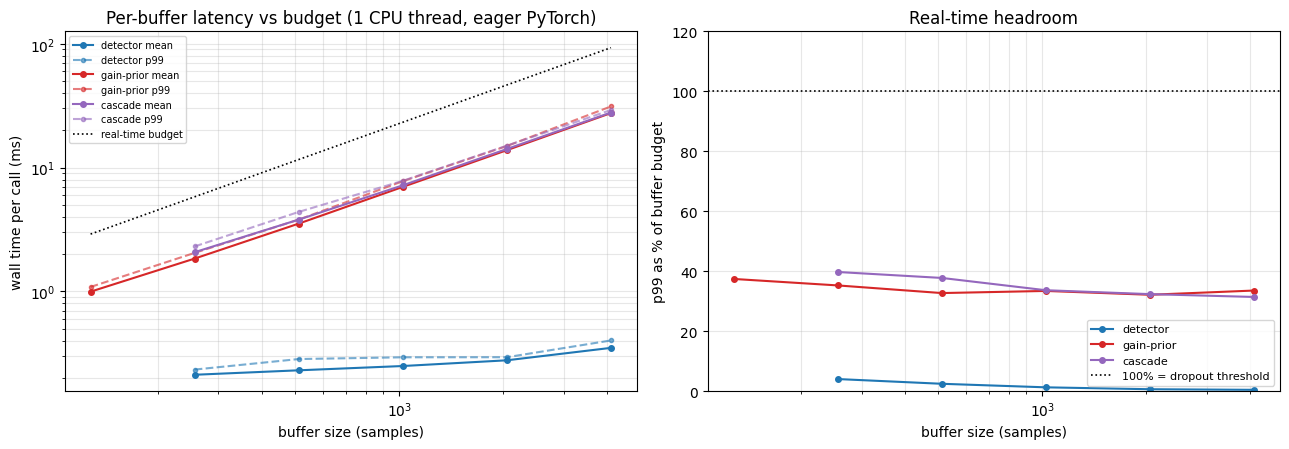

In [4]:
# -- 3. Plots ----------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
colors = {"detector": "#1f77b4", "gain-prior": "#d62728", "cascade": "#9467bd"}
for name, c in colors.items():
    s = lat_df[lat_df.stage == name].sort_values("buffer")
    ax1.loglog(s["buffer"], s["mean (ms)"], "o-", ms=4, color=c, label=f"{name} mean")
    ax1.loglog(s["buffer"], s["p99 (ms)"], "o--", ms=3, color=c, alpha=0.6,
               label=f"{name} p99")
bufs = np.array(sorted(lat_df["buffer"].unique()))
ax1.loglog(bufs, bufs / SR * 1000, "k:", lw=1.2, label="real-time budget")
ax1.set_xlabel("buffer size (samples)"); ax1.set_ylabel("wall time per call (ms)")
ax1.set_title("Per-buffer latency vs budget (1 CPU thread, eager PyTorch)")
ax1.grid(alpha=0.3, which="both"); ax1.legend(fontsize=7)

for name, c in colors.items():
    s = lat_df[lat_df.stage == name].sort_values("buffer")
    ax2.semilogx(s["buffer"], s["p99 %budget"], "o-", ms=4, color=c, label=name)
ax2.axhline(100, color="k", ls=":", lw=1.2, label="100% = dropout threshold")
ax2.set_xlabel("buffer size (samples)"); ax2.set_ylabel("p99 as % of buffer budget")
ax2.set_title("Real-time headroom"); ax2.grid(alpha=0.3, which="both")
ax2.legend(fontsize=8); ax2.set_ylim(0, max(120, ax2.get_ylim()[1]))
fig.tight_layout()
fig.savefig(OUT / "07_realtime_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# -- 4. Chunked-vs-full exactness at every benchmarked buffer size ------------------
# The property all eval numbers rest on: streaming with state carry must equal one
# full-sequence forward. Verified here per buffer size (float32 tolerance).

@torch.no_grad()
def gain_prior_full():
    MODEL.reset_states()
    return MODEL(DRY.unsqueeze(0), GR.unsqueeze(0), P).squeeze(0)


@torch.no_grad()
def detector_full():
    return DET(DRY.unsqueeze(0), P).squeeze(0)


ref_gp, ref_det = gain_prior_full(), detector_full()

print("gain-prior (tvcond block = 128 -> buffers must be 128-multiples):")
for buf in (128, 256, 512, 1024, 2048, 4096):
    MODEL.reset_states()
    outs = []
    with torch.no_grad():
        for o in range(0, N, buf):
            outs.append(MODEL(DRY[..., o:o + buf].unsqueeze(0),
                              GR[..., o:o + buf].unsqueeze(0), P).squeeze(0))
            MODEL.detach_states()
    diff = float((torch.cat(outs, -1) - ref_gp).abs().max())
    print(f"  buf {buf:5d}: max |chunked - full| = {diff:.2e}  "
          f"{'EXACT' if diff < 1e-5 else '** MISMATCH **'}")

print("detector (hop = 256 -> buffers must be 256-multiples):")
for buf in (256, 512, 1024, 2048, 4096):
    state, outs = None, []
    with torch.no_grad():
        for o in range(0, N, buf):
            g, state = DET(DRY[..., o:o + buf].unsqueeze(0), P, state,
                           return_state=True)
            outs.append(g.squeeze(0))
    diff = float((torch.cat(outs, -1) - ref_det).abs().max())
    print(f"  buf {buf:5d}: max |chunked - full| = {diff:.2e}  "
          f"{'EXACT' if diff < 1e-4 else '** MISMATCH **'}")

gain-prior (tvcond block = 128 -> buffers must be 128-multiples):


  buf   128: max |chunked - full| = 1.12e-08  EXACT


  buf   256: max |chunked - full| = 3.73e-09  EXACT


  buf   512: max |chunked - full| = 1.86e-09  EXACT


  buf  1024: max |chunked - full| = 1.86e-09  EXACT


...

  buf  4096: max |chunked - full| = 1.86e-09  EXACT
detector (hop = 256 -> buffers must be 256-multiples):


  buf   256: max |chunked - full| = 3.81e-06  EXACT


  buf   512: max |chunked - full| = 3.81e-06  EXACT


  buf  1024: max |chunked - full| = 2.86e-06  EXACT
  buf  2048: max |chunked - full| = 3.81e-06  EXACT


  buf  4096: max |chunked - full| = 2.86e-06  EXACT


In [6]:
# -- 5. Algorithmic latency accounting (independent of compute speed) ----------------
frame_ms = HOP / SR * 1000
block_ms = BLOCK / SR * 1000
print("Intrinsic (algorithmic) latency - what remains at infinite compute speed:")
print(f"  detector   : GR emitted once per {HOP}-sample frame  -> {frame_ms:.2f} ms granularity")
print(f"  gain stage : per-sample causal LSTM, zero lookahead; tvcond needs one")
print(f"               {BLOCK}-sample block buffered            -> {block_ms:.2f} ms")
print(f"  cascade    : min scheduling unit = 1 frame = {HOP} samples (= 2 cond blocks)")
print(f"               -> {frame_ms:.2f} ms end-to-end buffering, + the host I/O buffer")
print()
rtf = {r['stage']: r['RTF (x realtime)'] for r in bulk_rows}
print(f"Summary: cascade streams at {rtf['cascade']:.1f}x realtime on one CPU thread")
print(f"(eager PyTorch; compiled inference of 5-8k-param LSTMs is typically ~10x faster).")

Intrinsic (algorithmic) latency - what remains at infinite compute speed:
  detector   : GR emitted once per 256-sample frame  -> 5.80 ms granularity
  gain stage : per-sample causal LSTM, zero lookahead; tvcond needs one
               128-sample block buffered            -> 2.90 ms
  cascade    : min scheduling unit = 1 frame = 256 samples (= 2 cond blocks)
               -> 5.80 ms end-to-end buffering, + the host I/O buffer

Summary: cascade streams at 3.3x realtime on one CPU thread
(eager PyTorch; compiled inference of 5-8k-param LSTMs is typically ~10x faster).


## Reading the results

- **Feasibility claim**: read the RTF table — does the full cascade still stream
  above 1× realtime on one CPU thread in eager PyTorch? Unlike the fixed-detector
  twin (which was near-free, ~0.5–2 % of any buffer budget), stage 1 is now a learned
  conv frontend + LSTM, so it carries a real per-buffer cost; the sample-rate LSTM of
  the gain stage is still the dominant term (a property of the 02b SOTA architecture
  family, not of the gain-prior modification — Δg/color heads add two 33-param
  linears, the waveshaper a tiny MLP).
- **p99 vs mean**: quote the p99 column for real-time claims — a mean inside
  budget with p99 outside it still causes audible dropouts. Python/OS jitter
  inflates p99 here; a compiled deployment removes most of it.
- **Exactness table**: this is the formal statement that all offline eval metrics
  in notebooks 03–06 are *also* the streaming deployment's metrics — nothing changes
  at deployment except wall-clock speed.
- **Latency budget**: ≈ 5.8 ms intrinsic (one 256-sample predictor frame) + host
  buffer puts the system in the same class as typical hardware-insert round trips;
  there is no lookahead anywhere in the cascade, unlike limiter-style designs.
- For the thesis, pair this with notebook 05's cold-start figure: *when* the output
  becomes trustworthy (warmup) and *whether* it arrives on time (this notebook) are
  the two halves of the real-time story.